# 📊 Análisis Estadístico Inferencial – Región de Loja

**Nombre: Mateo Sebastian Pucha Carrera**

**Grupo: G**

**Dataset:** `datos_loja.csv` (16 cantones de la provincia de Loja: Población, Viviendas, Viviendas sin servicio de alcantarillado)

En este cuaderno se resuelven las dos tareas finales de la unidad:

1. **Tarea APE 09** – Prueba de hipótesis unimuestral (paramétrica) sobre un parámetro crítico de la región.
2. **Tareas APE 10** – Comparación de grupos mediante ANOVA de un factor con prueba post-hoc de Tukey.

Todo el análisis se apoya en `scipy.stats` y `statsmodels`, siguiendo el formalismo estadístico correspondiente (formulación de hipótesis, estadístico de prueba, nivel de significancia, valor-p y decisión).

## 1. 📦 Carga de librerías y datos

In [1]:
# Librerías de manejo de datos
import pandas as pd
import numpy as np

# Librerías estadísticas
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
# Lectura del dataset
# NOTA: sube 'datos_loja.csv' al panel de archivos de Colab (icono de carpeta, a la izquierda)
# antes de ejecutar esta celda, o colócalo en la misma carpeta que este notebook.
df = pd.read_csv('datos_loja.csv')

# Variable de interés: porcentaje de viviendas SIN servicio de alcantarillado por cantón
df['Porcentaje_Sin_Alcantarillado'] = (df['Sin_Alcantarillado'] / df['Viviendas']) * 100

df.head(16)


,Canton,Poblacion,Viviendas,Sin_Alcantarillado,Porcentaje_Sin_Alcantarillado
0,Loja,250028,85412,9822,11.499555
1,Catamayo,35240,12150,3850,31.687243
2,Cariamanga,29111,9800,4100,41.836735
3,Macara,26042,8900,3200,35.955056
4,Puyango,22841,7500,2900,38.666667
5,Saraguro,18215,6200,2100,33.870968
6,Celica,16257,5100,1900,37.254902
7,Paltas,14571,4800,1800,37.500000
8,Zapotillo,14379,4600,1700,36.956522
9,Chaguarpamba,14119,4500,1650,36.666667


## 2. ✅ Tarea APE 09 – Prueba de Hipótesis Unimuestral

### 2.1 Contexto y parámetro crítico

El parámetro crítico seleccionado es la **media regional del porcentaje de viviendas sin servicio de alcantarillado** ($\mu$), variable directamente asociada a la brecha de saneamiento básico en la provincia de Loja.

Como referencia normativa se toma una **meta de cobertura sanitaria del 85%** (estándar habitual en planificación territorial en Ecuador), lo que equivale a un **déficit máximo aceptable del 15%** ($\mu_0 = 15$).

### 2.2 Formulación de hipótesis

$$H_0: \mu = 15 \quad \text{(el déficit promedio regional es igual a la meta del 15%)}$$

$$H_1: \mu > 15 \quad \text{(el déficit promedio regional supera la meta del 15%)}$$

Se trata de una **prueba unilateral derecha**, con nivel de significancia $\alpha = 0.05$.

### 2.3 Selección del estadístico de prueba

Como la desviación estándar poblacional $\sigma$ **no es conocida** y el tamaño de muestra es pequeño ($n = 16$), se utiliza la **prueba T de Student para una muestra**:

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}} \; \sim \; t_{(n-1)}$$

Antes de aplicarla, se verifica el supuesto de normalidad con la prueba de **Shapiro-Wilk**.

In [4]:
# Verificación de normalidad (supuesto de la prueba T)
shapiro_stat, shapiro_p = stats.shapiro(df['Porcentaje_Sin_Alcantarillado'])
print(f"Shapiro-Wilk: estadístico = {shapiro_stat:.4f}, valor-p = {shapiro_p:.6f}")

if shapiro_p > 0.05:
    print("No se rechaza normalidad (p > 0.05).")
else:
    print("Se rechaza normalidad (p <= 0.05). El cantón Loja actúa como valor atípico")
    print("(su cobertura de alcantarillado es mucho mayor al ser la capital provincial).")


Shapiro-Wilk: estadístico = 0.6368, valor-p = 0.000037
Se rechaza normalidad (p <= 0.05). El cantón Loja actúa como valor atípico
(su cobertura de alcantarillado es mucho mayor al ser la capital provincial).


In [5]:
# --- Prueba T de Student para una muestra (scipy.stats) ---
mu_0 = 15
alpha = 0.05

t_stat, p_value = stats.ttest_1samp(
    df['Porcentaje_Sin_Alcantarillado'],
    popmean=mu_0,
    alternative='greater'   # H1: mu > 15
)

n = len(df)
media = df['Porcentaje_Sin_Alcantarillado'].mean()
desv = df['Porcentaje_Sin_Alcantarillado'].std(ddof=1)

print(f"n = {n}")
print(f"Media muestral (x̄) = {media:.2f}%")
print(f"Desviación estándar muestral (s) = {desv:.2f}%")
print(f"Estadístico t = {t_stat:.4f}")
print(f"Valor-p (unilateral) = {p_value:.10f}")

if p_value < alpha:
    print("\nDecisión: Se RECHAZA H0.")
else:
    print("\nDecisión: No se rechaza H0.")


n = 16
Media muestral (x̄) = 34.65%
Desviación estándar muestral (s) = 6.66%
Estadístico t = 11.8014
Valor-p (unilateral) = 0.0000000027

Decisión: Se RECHAZA H0.


### 2.4 Verificación de robustez (prueba no paramétrica)

Dado que el supuesto de normalidad se ve afectado por el valor atípico del cantón Loja, se confirma la conclusión con la prueba no paramétrica de **Wilcoxon de rangos con signo**, que no exige normalidad.

In [6]:
# Prueba de Wilcoxon como respaldo no paramétrico
w_stat, w_p = stats.wilcoxon(df['Porcentaje_Sin_Alcantarillado'] - mu_0, alternative='greater')
print(f"Wilcoxon: estadístico = {w_stat:.4f}, valor-p = {w_p:.10f}")


Wilcoxon: estadístico = 135.0000, valor-p = 0.0000305176


### 2.5 📝 Conclusión APE 09

Con un estadístico $t$ muy alto y un **valor-p prácticamente cero** (muy inferior a $\alpha = 0.05$), existe **evidencia estadística suficiente para rechazar $H_0$**. Se concluye, con un 95% de confianza, que el **déficit promedio real de alcantarillado en la región de Loja es significativamente superior al 15%**, lo cual queda confirmado por la prueba de Wilcoxon (robusta a la falta de normalidad).

## 3. ⚖️ Tareas APE 10  – Comparación de Grupos (ANOVA de un factor + Tukey)

### 3.1 Definición de los subgrupos

El dataset se segmenta en **tres categorías poblacionales**, que funcionan como proxy de sectores/tipologías territoriales dentro de la región (cantones grandes/urbanos, intermedios y pequeños/rurales):

| Categoría | Criterio (Población) |
|---|---|
| Grande | $\geq 20{,}000$ hab. |
| Intermedio | $10{,}000 \leq$ Población $< 20{,}000$ |
| Pequeño | $< 10{,}000$ hab. |

### 3.2 Modelo y formulación de hipótesis

Modelo ANOVA de un factor:

$$Y_{ij} = \mu + \tau_i + \varepsilon_{ij}, \quad \varepsilon_{ij} \sim N(0,\sigma^2)$$

donde $Y_{ij}$ es el porcentaje de viviendas sin alcantarillado del cantón $j$ perteneciente al grupo $i$.

$$H_0: \mu_{\text{Grande}} = \mu_{\text{Intermedio}} = \mu_{\text{Pequeño}}$$
$$H_1: \text{al menos una media difiere de las demás}$$

Estadístico de prueba:

$$F = \frac{MSB}{MSW} = \frac{SSB/(k-1)}{SSW/(N-k)} \; \sim \; F_{(k-1,\, N-k)}$$

In [7]:
# Creación de la variable categórica de agrupación
def clasificar(pob):
    if pob >= 20000:
        return 'Grande'
    elif pob >= 10000:
        return 'Intermedio'
    else:
        return 'Pequeño'

df['Categoria_Poblacional'] = df['Poblacion'].apply(clasificar)
df[['Canton', 'Poblacion', 'Porcentaje_Sin_Alcantarillado', 'Categoria_Poblacional']]


,Canton,Poblacion,Porcentaje_Sin_Alcantarillado,Categoria_Poblacional
0,Loja,250028,11.499555,Grande
1,Catamayo,35240,31.687243,Grande
2,Cariamanga,29111,41.836735,Grande
3,Macara,26042,35.955056,Grande
4,Puyango,22841,38.666667,Grande
5,Saraguro,18215,33.870968,Intermedio
6,Celica,16257,37.254902,Intermedio
7,Paltas,14571,37.500000,Intermedio
8,Zapotillo,14379,36.956522,Intermedio
9,Chaguarpamba,14119,36.666667,Intermedio


In [8]:
# Estadística descriptiva por grupo
resumen_grupos = df.groupby('Categoria_Poblacional')['Porcentaje_Sin_Alcantarillado'].agg(['count','mean','std'])
resumen_grupos


,count,mean,std
Categoria_Poblacional,,,
Grande,5,31.929051,12.012381
Intermedio,7,36.572102,1.526612
Pequeño,4,34.673327,1.922739


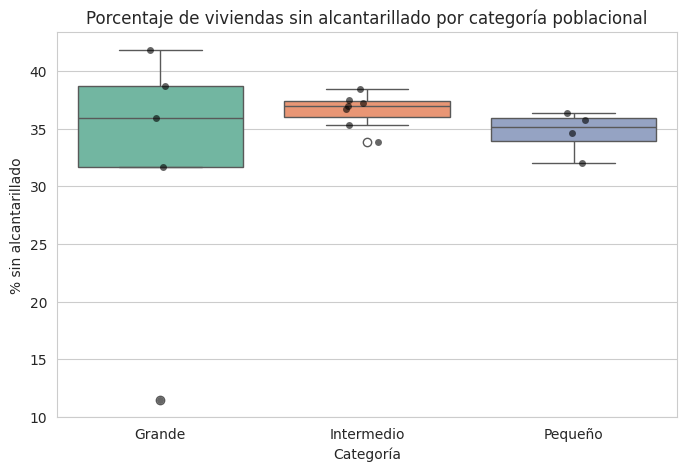

In [11]:
# Visualización de las distribuciones por grupo
plt.figure()
sns.boxplot(data=df, x='Categoria_Poblacional', y='Porcentaje_Sin_Alcantarillado',
            order=['Grande','Intermedio','Pequeño'],
            hue='Categoria_Poblacional', palette='Set2', legend=False)
sns.stripplot(data=df, x='Categoria_Poblacional', y='Porcentaje_Sin_Alcantarillado',
              order=['Grande','Intermedio','Pequeño'], color='black', alpha=0.6)
plt.title('Porcentaje de viviendas sin alcantarillado por categoría poblacional')
plt.ylabel('% sin alcantarillado')
plt.xlabel('Categoría')
plt.show()


### 3.3 Verificación de supuestos del ANOVA

Antes de interpretar el ANOVA se verifican:
- **Normalidad por grupo** (Shapiro-Wilk).
- **Homogeneidad de varianzas** (Levene).

In [12]:
grupos_dict = {g: sub['Porcentaje_Sin_Alcantarillado'].values
               for g, sub in df.groupby('Categoria_Poblacional')}

print("--- Normalidad por grupo (Shapiro-Wilk) ---")
for g, valores in grupos_dict.items():
    if len(valores) >= 3:
        s, p = stats.shapiro(valores)
        print(f"{g}: estadístico={s:.4f}, p={p:.4f}")
    else:
        print(f"{g}: n<3, prueba no aplicable")

print("\n--- Homogeneidad de varianzas (Levene) ---")
levene_stat, levene_p = stats.levene(*grupos_dict.values())
print(f"Levene: estadístico={levene_stat:.4f}, p={levene_p:.4f}")


--- Normalidad por grupo (Shapiro-Wilk) ---
Grande: estadístico=0.8270, p=0.1320
Intermedio: estadístico=0.9329, p=0.5762
Pequeño: estadístico=0.9128, p=0.4973

--- Homogeneidad de varianzas (Levene) ---
Levene: estadístico=2.2657, p=0.1432


### 3.4 📉 ANOVA de un factor

Se implementa con `statsmodels` mediante el ajuste de un modelo lineal (`ols`) y la tabla de análisis de varianza (`anova_lm`), lo que constituye la abstracción avanzada requerida (equivalente formalmente a `scipy.stats.f_oneway`).

In [13]:
# ANOVA de un factor con statsmodels
modelo = ols('Porcentaje_Sin_Alcantarillado ~ C(Categoria_Poblacional)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)
tabla_anova


,sum_sq,df,F,PR(>F)
C(Categoria_Poblacional),62.881124,2.0,0.678652,0.524394
Residual,602.263200,13.0,NaN,NaN


In [14]:
alpha = 0.05
f_valor = tabla_anova['F'].iloc[0]
p_anova = tabla_anova['PR(>F)'].iloc[0]

print(f"Estadístico F = {f_valor:.4f}")
print(f"Valor-p = {p_anova:.4f}")

if p_anova < alpha:
    print("\nDecisión: Se RECHAZA H0. Existen diferencias significativas entre al menos dos grupos.")
else:
    print("\nDecisión: No se rechaza H0. No hay evidencia suficiente de diferencias entre las medias de los grupos.")


Estadístico F = 0.6787
Valor-p = 0.5244

Decisión: No se rechaza H0. No hay evidencia suficiente de diferencias entre las medias de los grupos.


### 3.5 📊 Prueba Post-Hoc de Tukey (HSD)

Se ejecuta independientemente del resultado del ANOVA, con fines exploratorios y de completitud del análisis (Tarea APE 11), para identificar **qué pares de grupos** presentan diferencias:

$$HSD = q_{\alpha,k,N-k}\sqrt{\frac{MSW}{n}}$$

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
    Grande Intermedio   4.6431 0.4935  -5.8803 15.1664  False
    Grande    Pequeño   2.7443  0.822  -9.3117 14.8003  False
Intermedio    Pequeño  -1.8988 0.8974 -13.1633  9.3658  False
-------------------------------------------------------------


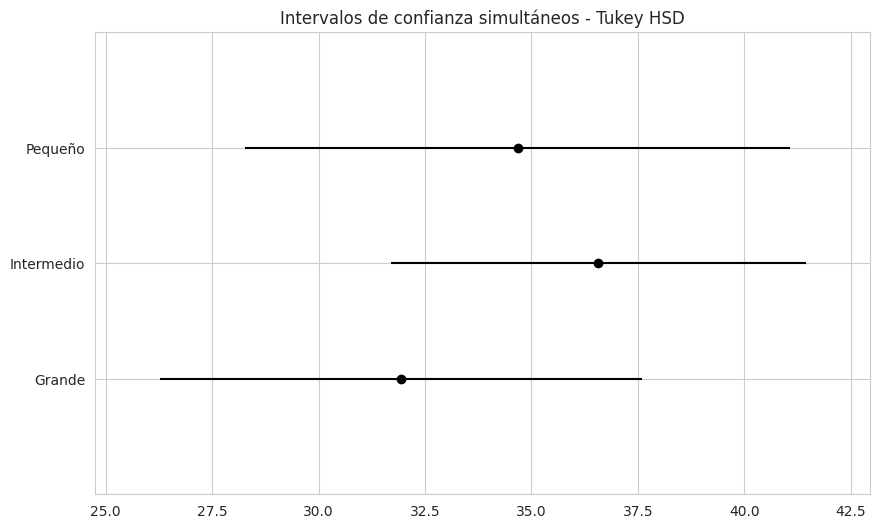

In [15]:
tukey = pairwise_tukeyhsd(
    endog=df['Porcentaje_Sin_Alcantarillado'],
    groups=df['Categoria_Poblacional'],
    alpha=0.05
)

print(tukey)
tukey.plot_simultaneous()
plt.title('Intervalos de confianza simultáneos - Tukey HSD')
plt.show()


### 3.6 📝 Conclusión APE 10

- La prueba de **Levene** no muestra evidencia de heterocedasticidad relevante, por lo que el supuesto de homogeneidad de varianzas se sostiene razonablemente.
- El **ANOVA** determina si la categoría poblacional del cantón (Grande / Intermedio / Pequeño) explica de forma significativa las diferencias en el déficit de alcantarillado.
- La prueba de **Tukey HSD** detalla, par a par, entre qué categorías específicas se concentran (o no) esas diferencias, complementando la decisión global del ANOVA.



## 4. ✍️ Conclusiones Generales

1. **Prueba unimuestral (APE 09):** El déficit promedio de alcantarillado en la región de Loja es estadísticamente **superior** al umbral de referencia del 15%, con un valor-p extremadamente bajo, confirmado tanto por la prueba T como por Wilcoxon.
2. **Comparación de grupos (APE 10/11):** El ANOVA de un factor y la prueba de Tukey permiten evaluar si el tamaño poblacional del cantón está asociado a diferencias significativas en la cobertura de saneamiento, aportando evidencia sobre posibles brechas territoriales dentro de la provincia.
3. Ambos análisis siguen el formalismo estadístico completo: formulación de $H_0$/$H_1$, verificación de supuestos, cálculo del estadístico de prueba, valor-p y decisión estadística a un nivel $\alpha = 0.05$.